# BloodMNIST – Federated Learning Experiments
**Variant 8**: FedMedian and Krum under data heterogeneity  
Dataset: BloodMNIST (8-class, 3-channel, multi-class classification)  
Resolutions tested: 28×28 and 64×64  
Models: Lightweight CNN baseline + ResNet18  
FL Strategies: FedMedian, Krum  
Partitioning: IID and non-IID (Dirichlet α)

Why bloodmnist?\
Justify model architecture.\
Justify hyperparameters.\
Why those alpha values?\
Why that method of partitioning? -- multiclass
Why 20 rounds?\
Why 5 clients?\
Why FedProx? --IID?\
Why local epoch 1? \
Why F1 is needed? --distribution plot for different alpha\
Why data poisoning? why 20%? --recovery\
Why 28x28 is good enough? --cost \
Test vs validation? why same or deviation and under attack conditions.

## 1. Install Dependencies

In [1]:
!pip install -q "flwr[simulation]>=1.8" flwr-datasets medmnist scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 79.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.5 MB/s eta 0:00:00
ERROR: pip's depend

## 2. Imports & Reproducibility

In [2]:
## Imports Libraries
import random, copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import f1_score
import json
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import models, transforms
from torch.utils.data import random_split, DataLoader, Subset

import medmnist
from medmnist import INFO

from flwr.common import NDArrays, Scalar, Metrics, Context, ndarrays_to_parameters, parameters_to_ndarrays
from flwr.client import NumPyClient, ClientApp
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg, FedMedian, Krum, FedProx
from flwr.simulation import run_simulation


## Seed: Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## check device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"MedMNIST v{medmnist.__version__}")

import warnings
warnings.filterwarnings("ignore")

Using device: cuda
MedMNIST v3.0.2


## 3. Dataset Configuration – BloodMNIST

In [3]:
data_flag = 'bloodmnist'
info = INFO[data_flag]
task = info['task']
N_CHANNELS = info['n_channels']   # 3 (RGB)
N_CLASSES = len(info['label'])   # 8 for bloodmnist
DataClass = getattr(medmnist, info['python_class'])

LABEL_NAMES = list(info['label'].values())
print(f"Task: {task}")
print(f"Channels: {N_CHANNELS}")
print(f"Classes: {N_CLASSES}")
print(f"Labels: {LABEL_NAMES}")

Task: multi-class
Channels: 3
Classes: 8
Labels: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


## 4. Default Experiment Configuration
The default hyperparameter settings that all the experiment utilize.\
In each specific experiment, the custom required hyperparameters can override the default values. 

In [4]:
## Hyperparameters
IMAGE_SIZE=28       # 28 or 64
BATCH_SIZE=64
NUM_CLIENTS=5        # ≥ 3 Iteration 02: Vary Clients
NUM_ROUNDS=5       # FL communication rounds
LOCAL_EPOCHS=1      # Iteration 03: Vary Local Epochs
LR=0.01
MOMENTUM=0.9

## Malicious Client Configurations
MALICIOUS_FRACTION = 0.2 
POISON_STRATEGY = 'random'  # 'random' or 'target'
POISON_TARGET_CLASS = 0     # only used when POISON_STRATEGY == 'target'

# # Partitioning: 'iid' or 'noniid'
# PARTITION_MODE = 'iid'   # set to 'noniid' for heterogeneous

# Non-IID Dirichlet concentration (lower = more heterogeneous)
DIRICHLET_ALPHA = 100 # Iteration 01: Vary Dirichlet Alpha

# Counter Attack Strategy: 'fedavg', 'fedprox', 'fedmedian' or 'krum'
STRATEGY_NAME = 'fedavg'
PROXIMAL_MU = 0.0

# Model: 'cnn' or 'resnet18'
MODEL_NAME = 'cnn'

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Clients: {NUM_CLIENTS}")
print(f"Rounds: {NUM_ROUNDS}")
# print(f"Data Heterogeneity: {PARTITION_MODE}")
print(f"Dirichlet Alpha: {DIRICHLET_ALPHA}")
print(f"Local Epochs: {LOCAL_EPOCHS}")
print(f"Strategy: {STRATEGY_NAME}")
print(f"proximal μ: {PROXIMAL_MU}")
print(f"Model: {MODEL_NAME}")

Image size: 28x28
Clients: 5
Rounds: 5
Dirichlet Alpha: 100
Local Epochs: 1
Strategy: fedavg
proximal μ: 0.0
Model: cnn


## 5. Data Loading

In [5]:
DOWNLOAD = True

def make_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[.5]*3, std=[.5]*3),
    ])

transform = make_transform(IMAGE_SIZE)

train_dataset_full = DataClass(split='train', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)
val_dataset = DataClass(split='val', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)
test_dataset = DataClass(split='test', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)

# data loaders
train_loader_full = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset_full)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

100%|██████████| 35.5M/35.5M [00:03<00:00, 11.8MB/s]


Train: 11959 | Val: 1712 | Test: 3421


### Montage
View Samples of Images from training set

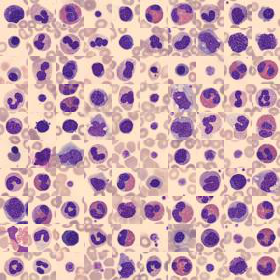

In [6]:
train_dataset_full.montage(length=10)

## 6. Data Partitioning

In [7]:
def dirichlet_partition(dataset, num_clients, alpha, seed=SEED):
    """Non-IID Dirichlet partition - skews class distribution per client."""
    # Extract integer labels
    labels = []
    for _, lbl in dataset:
        if isinstance(lbl, (np.ndarray, torch.Tensor)):
            lbl = int(np.array(lbl).squeeze())
        labels.append(int(lbl))
    labels = np.array(labels)
    n_classes = len(np.unique(labels))

    np.random.seed(seed)
    class_indices = {c: np.where(labels == c)[0].tolist() for c in range(n_classes)}
    # Shuffle within each class
    for c in class_indices:
        np.random.shuffle(class_indices[c])

    client_indices = [[] for _ in range(num_clients)]
    for c in range(n_classes):
        idx = class_indices[c]
        proportions = np.random.dirichlet([alpha] * num_clients)
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        splits = np.split(idx, proportions)
        for cid, split in enumerate(splits):
            client_indices[cid].extend(split.tolist())

    return [Subset(dataset, idxs) for idxs in client_indices]

partitions = dirichlet_partition(train_dataset_full, NUM_CLIENTS, DIRICHLET_ALPHA)
for i, p in enumerate(partitions):
    print(f"Client {i}: {len(p)} samples")

Client 0: 2262 samples
Client 1: 2489 samples
Client 2: 2406 samples
Client 3: 2427 samples
Client 4: 2375 samples


### Partition Label Distribution

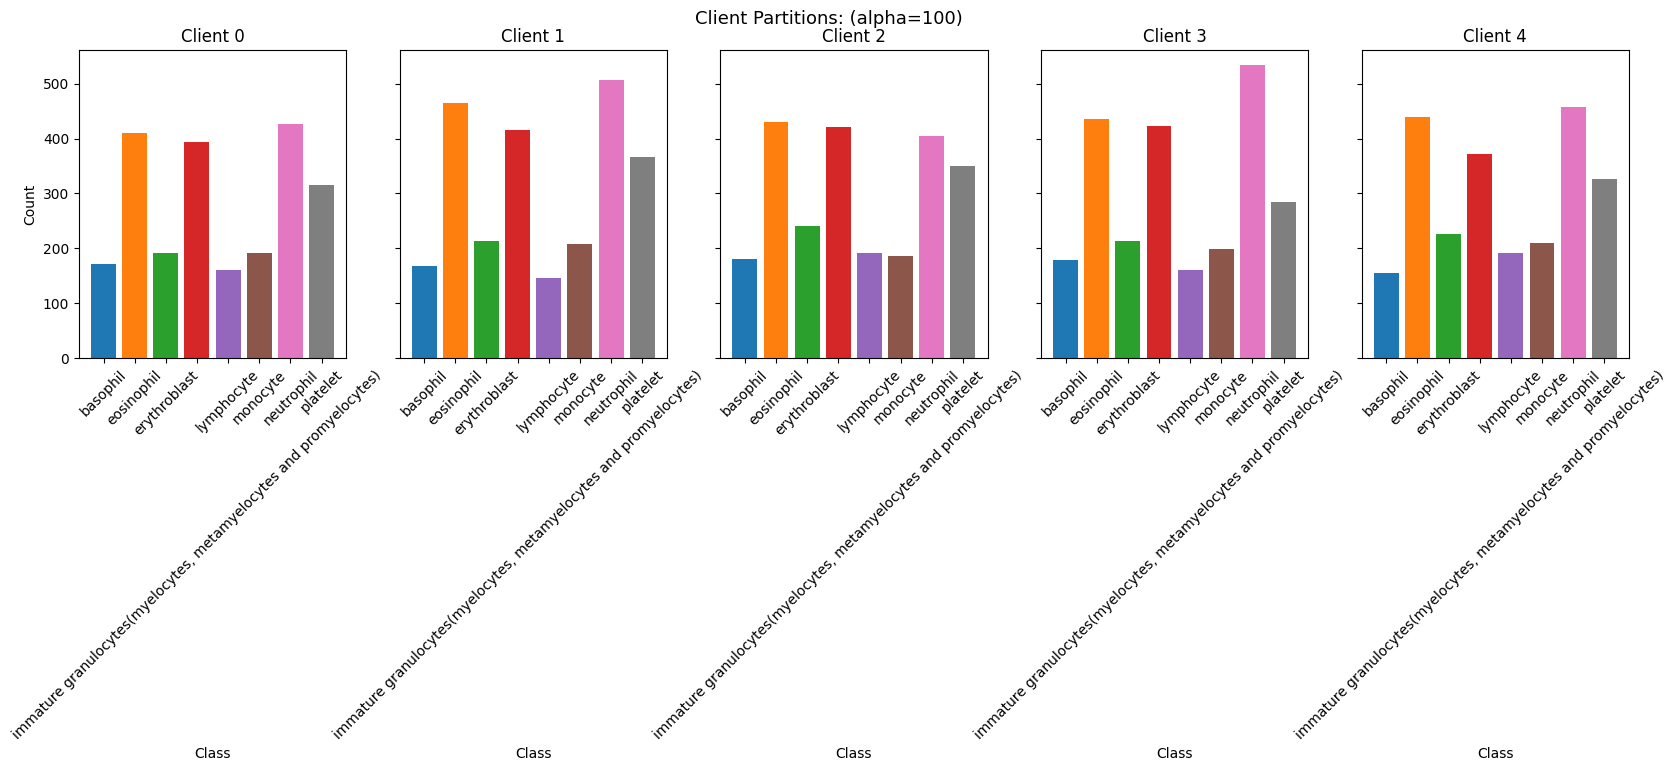

In [8]:
def extract_labels(subset):
    labels = []
    for _, lbl in subset:
        if isinstance(lbl, (np.ndarray, torch.Tensor)):
            lbl = int(np.array(lbl).squeeze())
        labels.append(int(lbl))
    return labels

fig, axes = plt.subplots(1, NUM_CLIENTS, figsize=(4*NUM_CLIENTS, 4), sharey=True)
for cid, part in enumerate(partitions):
    lbls = extract_labels(part)
    ax = axes[cid] if NUM_CLIENTS > 1 else axes
    counts = [lbls.count(c) for c in range(N_CLASSES)]
    ax.bar(LABEL_NAMES, counts, color=sns.color_palette("tab10", N_CLASSES))
    ax.set_title(f"Client {cid}")
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel("Class")
    if cid == 0:
        ax.set_ylabel("Count")

fig.suptitle(f"Client Partitions: (alpha={DIRICHLET_ALPHA})", fontsize=13)
plt.tight_layout()
plt.savefig(f"client_partitions_alpha_{DIRICHLET_ALPHA}_{IMAGE_SIZE}.png", dpi=120, bbox_inches='tight')
plt.show()

## 7. Model Architectures

In [9]:
class LightCNN(nn.Module):
    """Lightweight CNN baseline for BloodMNIST."""
    def __init__(self, n_channels=3, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(n_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def create_resnet18(n_channels=3, n_classes=8, image_size=28):
    model = models.resnet18(weights=None)
    # Adapt first conv for smaller images
    if image_size <= 32:
        model.conv1 = nn.Conv2d(n_channels, 64, kernel_size=3,
                                 stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
    else:
        model.conv1 = nn.Conv2d(n_channels, 64, kernel_size=7,
                                 stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


def create_model(name=MODEL_NAME, image_size=IMAGE_SIZE):
    if name == 'cnn':
        return LightCNN(N_CHANNELS, N_CLASSES)
    else:
        return create_resnet18(N_CHANNELS, N_CLASSES, image_size)

# model parameters
m = create_model()
params = sum(p.numel() for p in m.parameters())
print(f"Model: {MODEL_NAME} | Parameters: {params:,}")


Model: cnn | Parameters: 620,296


## 8. Training & Evaluation Functions

In [10]:
from sklearn.metrics import f1_score

criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, proximal_mu, global_params, device):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze(1).long().to(device)
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)

        # Proximal term: μ/2 * ||w - w_global||²
        if proximal_mu > 0.0:
            prox = sum(
                ((p - g) ** 2).sum()
                for p, g in zip(model.parameters(), global_params)
            )
            loss = loss + (proximal_mu / 2.0) * prox

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)
            out  = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = (np.array(y_pred) == np.array(y_true)).mean()
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return avg_loss, acc, f1

# Centralised baseline
def run_centralised(epochs=5, lr=LR, model_name=MODEL_NAME):
    model = create_model(model_name).to(DEVICE)
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=MOMENTUM)
    history = []
    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader_full, opt, 0.0, [], DEVICE)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader)
        history.append(dict(epoch=epoch, train_loss=tr_loss,
                            val_loss=val_loss, val_acc=val_acc, val_f1=val_f1))
        print(f"Epoch {epoch}/{epochs} | train_loss={tr_loss:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")
    test_loss, test_acc, test_f1 = evaluate(model, test_loader)
    print(f"\nTest | loss={test_loss:.4f} acc={test_acc:.4f} f1={test_f1:.4f}")
    return model, history

In [11]:
### Data Poisoning Attack: Label Flipping
class LabelFlippingDataset(data.Dataset):
    """
    Dataset wrapper that flips labels according to a specified strategy.
    """
    def __init__(self, dataset, n_classes=N_CLASSES, strategy='random', target_class=0, seed=SEED):
        self.dataset = dataset
        self.n_classes = n_classes
        self.strategy = strategy
        self.target_class = target_class
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if isinstance(label, (np.ndarray, torch.Tensor)):
            label = int(np.array(label).squeeze())
        else:
            label = int(label)

        if self.strategy == 'target':
            flipped = self.target_class
        else:
            choices = [c for c in range(self.n_classes) if c != label]
            flipped = int(self.rng.choice(choices))

        return image, np.array([flipped], dtype=np.int64)

### model sanity check

In [12]:
# central_model, central_history = run_centralised(epochs=2)

## 9. Flower FL Components

In [13]:
### Parameter helpers ###
def get_params(model):
    return [v.cpu().numpy() for _, v in model.state_dict().items()]

def set_params(model, parameters):
    keys = list(model.state_dict().keys())
    state = OrderedDict({k: torch.tensor(v) for k, v in zip(keys, parameters)})
    model.load_state_dict(state, strict=True)

In [14]:
################## CLIENT ##################
# Resolve device safely - works whether or not CUDA is available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Host device: {DEVICE}")

class FlowerClient(NumPyClient):
    def __init__(self, trainloader, valloader, model_name=MODEL_NAME,
                 local_epochs=LOCAL_EPOCHS, lr=LR, proximal_mu=0.0):
        self.trainloader = trainloader
        self.valloader = valloader
        self.local_epochs = local_epochs
        self.lr = lr
        self.proximal_mu = proximal_mu   # 0.0 means standard FedAvg/FedMedian/Krum behaviour
        self.model_name = model_name
        self.model = create_model(model_name)

    @property
    def device(self):
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def fit(self, parameters, config):
        device = self.device
        self.model.to(device)
        print(f"  Client running on: {device}")
        set_params(self.model, parameters)
        opt = optim.SGD(self.model.parameters(), lr=self.lr, momentum=MOMENTUM)
        # Keep a frozen copy of the global model for the proximal penalty
        global_params = [p.detach().clone() for p in self.model.parameters()]
        print(f"local_epochs={self.local_epochs}, lr={self.lr}, proximal_mu={self.proximal_mu}")
        for _ in range(self.local_epochs):
            train_one_epoch(self.model, self.trainloader, opt, self.proximal_mu, global_params, device)
        return get_params(self.model), len(self.trainloader.dataset), {}

    def evaluate(self, parameters, config):
        device = self.device
        self.model.to(device)
        set_params(self.model, parameters)
        loss, acc, f1 = evaluate(self.model, self.valloader, device)
        return float(loss), len(self.valloader.dataset), {"accuracy": acc, "f1": f1}

Host device: cuda


In [15]:
######### CLIENT FUNCTION #########
def make_client_fn(partitions, model_name=MODEL_NAME, local_epochs=LOCAL_EPOCHS, proximal_mu=0.0, malicious_fraction=0.0, poison_strategy='random', 
                   poison_target_class=0):    
    num_clients = len(partitions)
    n_malicious = int(np.floor(malicious_fraction * num_clients))
    malicious_ids = set(range(n_malicious))   # first n clients are malicious

    if n_malicious > 0:
        print(f" Malicious clients : {sorted(malicious_ids)} "
              f"({n_malicious}/{num_clients}, strategy='{poison_strategy}')")

    def client_fn(context: Context):
        pid = int(context.node_config["partition-id"])
        part = partitions[pid]

        # Poison the partition if this client is malicious
        if pid in malicious_ids:
            part = LabelFlippingDataset(part, n_classes=N_CLASSES, strategy=poison_strategy, 
                                        target_class=poison_target_class)

        val_sz = max(1, int(len(part) * 0.1))
        train_sz = len(part) - val_sz
        tr, va = random_split(part, [train_sz, val_sz], generator=torch.Generator().manual_seed(SEED))
        tr_loader = DataLoader(tr, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=False)
        va_loader = DataLoader(va, BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=False)

        return FlowerClient(tr_loader, va_loader, model_name, proximal_mu=proximal_mu, local_epochs=local_epochs).to_client()

    return client_fn

In [16]:
#### AGGREGATE METRICS #####
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    total = sum(n for n, _ in metrics)
    acc = sum(n * m["accuracy"] for n, m in metrics) / total
    f1 = sum(n * m["f1"] for n, m in metrics) / total
    return {"accuracy": acc, "f1": f1}

In [17]:
############## LOGGING ##############
class LoggingStrategy:
    """Records per-round metrics."""

    def __init__(self, strategy):
        self._strategy = strategy
        self.history = []
        self.pending_test = {}

    def __getattr__(self, name):
        return getattr(self._strategy, name)
    
    def aggregate_evaluate(self, server_round, results, failures):
        aggregated = self._strategy.aggregate_evaluate(server_round, results, failures)
        if aggregated is not None:
            loss, metrics = aggregated
            self.history.append({
                "round": server_round,
                "val_loss": loss,
                "accuracy": metrics.get("accuracy", float("nan")),
                "f1": metrics.get("f1", float("nan")),
                "test_loss": float("nan"),
                "test_acc":  float("nan"),
                "test_f1":   float("nan"),
            })
        return aggregated

    def configure_fit(self, server_round, parameters, client_manager):
        return self._strategy.configure_fit(server_round, parameters, client_manager)

    def configure_evaluate(self, server_round, parameters, client_manager):
        return self._strategy.configure_evaluate(server_round, parameters, client_manager)

    def aggregate_fit(self, server_round, results, failures):
        return self._strategy.aggregate_fit(server_round, results, failures)

    def evaluate(self, server_round, parameters):
        return self._strategy.evaluate(server_round, parameters)

    def initialize_parameters(self, client_manager):
        return self._strategy.initialize_parameters(client_manager)

## 10. Run FL Experiment

In [18]:
def build_strategy(name, model, num_clients, n_malicious=0):
    """Return the chosen Flower strategy."""
    ndarrays = get_params(model)
    init_params = ndarrays_to_parameters(ndarrays)

    common = dict(
        fraction_fit = 1.0,
        fraction_evaluate = 1.0,
        min_fit_clients = num_clients,
        min_evaluate_clients = num_clients,
        min_available_clients = num_clients,
        evaluate_metrics_aggregation_fn = weighted_average,
        initial_parameters = init_params,
    )

    if name == 'fedavg':
        return FedAvg(**common)
    elif name == 'fedmedian':
        return FedMedian(**common)
    elif name == 'fedprox':
        return FedProx(proximal_mu=0.1, **common)   # proximal_mu is the μ penalty term
    elif name == 'krum':
        return Krum(num_malicious_clients=n_malicious, min_fit_clients=num_clients,
                min_evaluate_clients=num_clients, min_available_clients=num_clients,
                evaluate_metrics_aggregation_fn=weighted_average,
                initial_parameters=init_params)
    else:
        raise ValueError(f"Unknown strategy: {name!r}. "
                         f"Choose from: fedavg, fedmedian, fedprox, krum")

In [19]:
# Detect how much GPU to give each worker
def get_backend_config(num_clients: int) -> dict:
    if torch.cuda.is_available():
        # Give each client a fraction of one GPU
        # e.g. 5 clients → 0.2 GPU each (they share the physical GPU)
        gpu_per_client = 1.0 / num_clients
        print(f"GPU detected — allocating {gpu_per_client:.2f} GPU per client")
        return {"client_resources": {"num_cpus": 1, "num_gpus": gpu_per_client}}
    else:
        print("No GPU detected — running on CPU")
        return {"client_resources": {"num_cpus": 1, "num_gpus": 0.0}}

In [20]:
def run_fl_experiment(
        strategy_name = STRATEGY_NAME,
        model_name = MODEL_NAME,
        image_size = IMAGE_SIZE,
        local_epochs = LOCAL_EPOCHS,
        num_clients = NUM_CLIENTS,
        num_rounds = NUM_ROUNDS,
        alpha = DIRICHLET_ALPHA,
        proximal_mu = PROXIMAL_MU,
        malicious_fraction = 0.0,
        poison_strategy = 'random',
        poison_target_class= 0,
):
    """Full FL experiment returning the round history."""

    n_malicious = int(np.floor(malicious_fraction * num_clients))
    print(f"\n{'='*100}")
    print(f"Experiment: strategy={strategy_name} | model={model_name} | "
          f"size={image_size} | alpha={alpha} | num_clients={num_clients} | rounds={num_rounds} | "
          f" mu={proximal_mu if strategy_name=='fedprox' else 'n/a'}")
    print(f" malicious={n_malicious}/{num_clients} ({malicious_fraction:.0%})  poison='{poison_strategy}'")
    print(f"{'='*100}\n")

    # 1. Partitions (re-built with correct image_size transform)
    tf = make_transform(image_size)
    ds_train = DataClass(split='train', transform=tf, download=True, size=image_size)
    ds_test  = DataClass(split='test', transform=tf, download=True, size=image_size)
    test_loader_exp = DataLoader(ds_test, BATCH_SIZE * 2,shuffle=False, num_workers=2, pin_memory=True)

    parts = dirichlet_partition(ds_train, num_clients, alpha)
    mu = proximal_mu if strategy_name == 'fedprox' else 0.0

    # 2. Strategy (with logging wrapper)
    global_model = create_model(model_name, image_size)
    base_strategy = build_strategy(strategy_name, global_model, num_clients, n_malicious=n_malicious)
    logged_strategy = LoggingStrategy(base_strategy)
    eval_model = create_model(model_name, image_size)
    original_strategy_evaluate = base_strategy.evaluate

    def evaluate_with_test(server_round, parameters):
        result = original_strategy_evaluate(server_round, parameters)

        # Load global parameters into the proxy model and evaluate on test set
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        set_params(eval_model, parameters_to_ndarrays(parameters))
        test_loss, test_acc, test_f1 = evaluate(eval_model, test_loader_exp, device)
        logged_strategy.pending_test[server_round] = {
            "test_loss": test_loss,
            "test_acc":  test_acc,
            "test_f1":   test_f1,
        }
        print(f"  [Round {server_round}] test_loss={test_loss:.4f}  "
              f"test_acc={test_acc:.4f}  test_f1={test_f1:.4f}")
        return result

    base_strategy.evaluate = evaluate_with_test

    # 3. server_fn
    def server_fn(context: Context):
        return ServerAppComponents(
            strategy = logged_strategy,
            config = ServerConfig(num_rounds=num_rounds),
        )

    # 4. client_fn
    server_app = ServerApp(server_fn=server_fn)
    client_app = ClientApp(client_fn=make_client_fn(parts, model_name, local_epochs=local_epochs, proximal_mu=mu, malicious_fraction=malicious_fraction,
                                                    poison_strategy=poison_strategy,poison_target_class=poison_target_class))

    run_simulation(
        server_app = server_app,
        client_app = client_app,
        num_supernodes = num_clients,
        backend_config = get_backend_config(num_clients),
    )
    
    # Merge test metrics into the round history
    for entry in logged_strategy.history:
        r = entry["round"]
        if r in logged_strategy.pending_test:
            entry.update(logged_strategy.pending_test[r])

    return logged_strategy.history

### Test Experiment (configured above)

In [21]:
# history = run_fl_experiment()

# # Print summary
# print("\nRound | Val Loss | Accuracy | F1")
# print("-" * 40)
# for r in history:
#     print(f"  {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")

## 11. Plotting Utilities

In [22]:
############################################## LOCAL LOGGING UTILITIES (OPTIONAL) ##############################################
# from importlib.resources import files


# def save_history(histories: dict, filename: str):
#     """Save experiment histories to a JSON file."""
#     out = {
#         "saved_at": datetime.now().isoformat(),
#         "runs": {
#             label: hist for label, hist in histories.items()
#         }
#     }
#     with open(filename, "w") as f:
#         json.dump(out, f, indent=2)
#     print(f"Saved: {filename}")


# def plot_history(histories: dict, title: str, filename: str):
#     """Plot val_loss, accuracy and F1; also saves a JSON sidecar."""
#     fig, axes = plt.subplots(1, 3, figsize=(16, 4))
#     metrics = [("val_loss", "Validation Loss"),
#                ("accuracy", "Accuracy"),
#                ("f1", "Macro F1")]

#     for ax, (key, ylabel) in zip(axes, metrics):
#         for label, hist in histories.items():
#             rounds = [r["round"] for r in hist]
#             vals   = [r[key]    for r in hist]
#             ax.plot(rounds, vals, marker='o', label=label)
#         ax.set_xlabel("Round")
#         ax.set_ylabel(ylabel)
#         ax.set_title(ylabel)
#         ax.legend()
#         ax.grid(True, linestyle='--', alpha=0.5)

#     fig.suptitle(title, fontsize=13, fontweight='bold')
#     plt.tight_layout()
#     plt.savefig(filename + ".png", dpi=120, bbox_inches='tight')
#     plt.show()
#     print(f"Saved: {filename}.png")

#     # JSON sidecar: same base name, different extension
#     json_filename = filename + ".json"
#     save_history(histories, json_filename)

In [23]:
########################## GOOGLE DRIVE LOGGING (OPTIONAL) ##########################
from google.colab import drive
from sklearn import metrics
drive.mount("/content/drive")

# Set a base output directory
OUTPUT_DIR = "/content/drive/MyDrive/dfl-mednist-tp"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_history(histories: dict, filename: str):
    path = os.path.join(OUTPUT_DIR, filename)
    summary = {}
    for label, hist in histories.items():
        if hist:
            last = hist[-1]
            summary[label] = {
                "final_val_loss": last.get("val_loss", float("nan")),
                "final_val_acc": last.get("accuracy", float("nan")),
                "final_val_f1": last.get("f1", float("nan")),
                "final_test_loss": last.get("test_loss", float("nan")),
                "final_test_acc": last.get("test_acc", float("nan")),
                "final_test_f1": last.get("test_f1", float("nan"))
            }

    out = {
        "saved_at":datetime.now().isoformat(),
        "summary":summary,
        "runs":{label: hist for label, hist in histories.items()},
    }
    with open(path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Saved: {path}")

def plot_history(histories: dict, title: str, filename: str):
    metrics = [
        ("val_loss", "Val Loss", "-"),
        ("accuracy", "Val Accuracy", "-"),
        ("f1", "Val Macro F1",  "-"),
        ("test_loss", "Test Loss", "--"),
        ("test_acc", "Test Accuracy", "--"),
        ("test_f1", "Test Macro F1", "--")
    ]
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()

    for ax, (key, ylabel, ls) in zip(axes, metrics):
        for label, hist in histories.items():
            rounds = [r["round"] for r in hist]
            vals   = [r.get(key, float("nan")) for r in hist]
            ax.plot(rounds, vals, marker='o', linestyle=ls, label=label)
        ax.set_xlabel("Round")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

    png_path = os.path.join(OUTPUT_DIR, filename + ".png")
    plt.savefig(png_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {png_path}")

    json_filename = filename + ".json"
    save_history(histories, json_filename)

Mounted at /content/drive


## 12. Experiment Set 1 – IID vs Non-IID (FedAvg, CNN, 28×28)
Non-IID uses Dirichlet α=0.5, which creates realistic per-client class imbalance.

In [ ]:
exp1_iid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=100, num_rounds=20)
exp1_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.01, num_rounds=20)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp1_iid:
    print(f" IID α=100 |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")
print("-" * 90)
for r in exp1_noniid:
    print(f" Non-IID α=0.01 |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

In [ ]:
plot_history(
    {"IID α=100": exp1_iid, "Non-IID α=0.01": exp1_noniid},
    title = "IID vs Non-IID – FedAvg | CNN | 28×28",
    filename = "exp1_heterogeneity_fedavg_cnn_28"
)

## 13. Experiment Set 2 – CNN vs ResNet18 (FedAvg, IID, 28×28)
Compare the lightweight baseline model against ResNet18 under the same FL setup.

In [26]:

exp2_resnet = run_fl_experiment(strategy_name='fedavg', model_name='resnet18', image_size=28, num_rounds=20)
exp2_cnn = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, num_rounds=20)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp2_cnn:
    print(f" CNN |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")
print("-" * 90)
for r in exp2_resnet:
    print(f" ResNet18 |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")



Experiment: strategy=fedavg | model=resnet18 | size=28 | alpha=100 | num_clients=5 | rounds=20 |  mu=n/a
 malicious=0/5 (0%)  poison='random'




            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=20, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters


GPU detected — allocating 0.20 GPU per client


INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


  [Round 0] test_loss=2.1643  test_acc=0.1640  test_f1=0.0359


...

  [Round 20] test_loss=0.3498  test_acc=0.8714  test_f1=0.8515


(ClientAppActor pid=14920) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=14920) is multi-threaded, use of fork() may lead to deadlocks in the child. [repeated 5x across cluster]
(ClientAppActor pid=14920)   self.pid = os.fork() [repeated 5x across cluster]
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 187.95s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.5044222554536997
INFO :      		round 2: 0.6245433629708238
INFO :      		round 3: 0.545121108246569
INFO :      		round 4: 0.5957617839643762
INFO :      		round 5: 0.6715185061684198
INFO :      		round 6: 0.4721388895773428
INFO :      		round 7: 0.4201757095985221
INFO :      		round 8: 0.3568704485993173
INFO :      		round 9: 0.326590735674504
INFO :      		round 10: 0.4015125128919101
INFO :      		round 11: 0.36621779148456735
INFO :      		round 12: 0.44811442794164286

(ClientAppActor pid=14920)   Client running on: cuda [repeated 4x across cluster]


(ClientAppActor pid=14921) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=14921) is multi-threaded, use of fork() may lead to deadlocks in the child. [repeated 2x across cluster]
(ClientAppActor pid=14921)   self.pid = os.fork() [repeated 2x across cluster]



Experiment | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1
------------------------------------------------------------------------------------------
 CNN | 1  |  1.5044  |  0.3621  | 0.3216 | 1.4423  |  0.3747  | 0.3261
 CNN | 2  |  0.6245  |  0.7628  | 0.6911 | 0.5958  |  0.7717  | 0.6959
 CNN | 3  |  0.5451  |  0.8005  | 0.7567 | 0.5349  |  0.8261  | 0.7920
 CNN | 4  |  0.5958  |  0.7938  | 0.7708 | 0.5744  |  0.8103  | 0.7899
 CNN | 5  |  0.6715  |  0.7619  | 0.7268 | 0.6457  |  0.7606  | 0.7230
 CNN | 6  |  0.4721  |  0.8315  | 0.8005 | 0.4555  |  0.8384  | 0.8108
 CNN | 7  |  0.4202  |  0.8500  | 0.8221 | 0.4141  |  0.8460  | 0.8117
 CNN | 8  |  0.3569  |  0.8785  | 0.8606 | 0.3570  |  0.8667  | 0.8479
 CNN | 9  |  0.3266  |  0.8902  | 0.8758 | 0.3328  |  0.8781  | 0.8651
 CNN |10  |  0.4015  |  0.8407  | 0.8191 | 0.4172  |  0.8287  | 0.8065
 CNN |11  |  0.3662  |  0.8768  | 0.8468 | 0.3693  |  0.8594  | 0.8308
 CNN |12  |  0.4481  |  0.8340  | 0.8081 | 

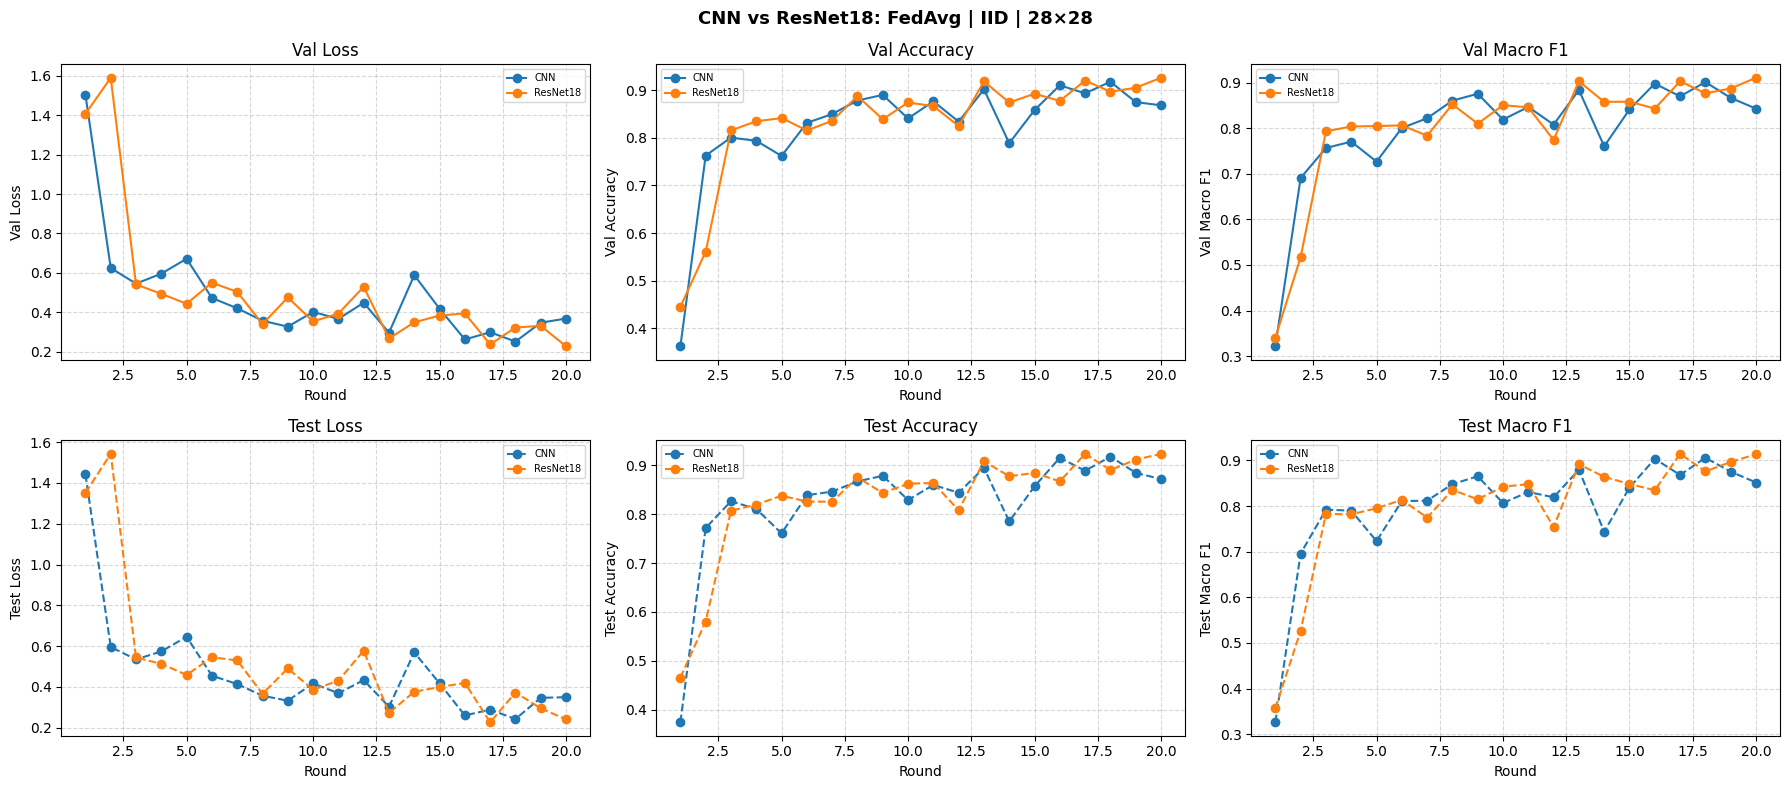

Saved: /content/drive/MyDrive/dfl-mednist-tp/exp2_model_fedavg_iid_28.png
Saved: /content/drive/MyDrive/dfl-mednist-tp/exp2_model_fedavg_iid_28.json


In [27]:
plot_history(
    {"CNN": exp2_cnn, "ResNet18": exp2_resnet},
    title = "CNN vs ResNet18: FedAvg | IID | 28×28",
    filename = "exp2_model_fedavg_iid_28"
)

## 14. Experiment Set 3 – FedAvg vs FedProx vs FedMedian vs Krum (IID, CNN, 28×28)
All strategies tested under identical IID conditions to establish a fair baseline comparison.

In [ ]:
exp3_fedmedian = run_fl_experiment(strategy_name='fedmedian',model_name='cnn', image_size=28, num_rounds=20)
exp3_krum = run_fl_experiment(strategy_name='krum', model_name='cnn', image_size=28, num_rounds=20)
exp3_fedavg = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, num_rounds=20)
exp3_fedprox = run_fl_experiment(strategy_name='fedprox', proximal_mu=0.1, model_name='cnn', image_size=28, num_rounds=20)

# Print summary
print("\nAlgorithm | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp3_fedmedian:
    print(f"  FedMedian | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

for r in exp3_krum:
    print(f"  Krum | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}" | f" | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

for r in exp3_fedavg:
    print(f"  FedAvg | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}" | f" | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

for r in exp3_fedprox:
    print(f"  FedProx | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

In [ ]:
plot_history(
    {"FedMedian": exp3_fedmedian, "Krum": exp3_krum, "FedAvg": exp3_fedavg, "FedProx": exp3_fedprox},
    title = "Strategy Comparison - IID | CNN | 28×28",
    filename = "exp3_strategy_iid_cnn_28"
)

## 15. Experiment Set 4 – Resolution 28×28 vs 64×64 (FedMedian, CNN, Non-IID)
Higher resolution may improve accuracy but increases communication & compute cost.


In [ ]:
exp4_28 = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.01,num_rounds=20)
exp4_64 = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=64, alpha=0.01,num_rounds=20)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp4_28:
    print(f" 28×28 | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")
print("-" * 90)
for r in exp4_64:
    print(f" 64×64 | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

In [ ]:
plot_history(
    {"28×28": exp4_28, "64×64": exp4_64},
    title    = "Resolution Comparison – FedAvg | CNN | Non-IID α=0.01",
    filename = "exp4_resolution_fedavg_cnn_noniid",
)

## 16. Experiment Set 5 – Robustness: FedMed & Krum with Simulated Malicious Clients (data poisoning)
Krum is designed to be Byzantine-robust. Here we compare it against FedMedian under non-IID.


In [ ]:
POISON_FRAC = 0.2 
poison_results = {}
exp5_fedavg_mal_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20, 
                                       malicious_fraction  = POISON_FRAC)
exp5_fedmedian_mal_noniid = run_fl_experiment(strategy_name='fedmedian', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20,
                                          malicious_fraction  = POISON_FRAC)
exp5_krum_mal_noniid = run_fl_experiment(strategy_name='krum', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20,
                                     malicious_fraction  = POISON_FRAC)
exp5_fedavg_clean_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20, 
                                       malicious_fraction = 0)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1")
print("-" * 60)
for r in exp5_fedavg_mal_noniid:
    print(f" FedAvg (malicious={POISON_FRAC}) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp5_fedmedian_mal_noniid:
    print(f" FedMedian (malicious={POISON_FRAC}) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp5_krum_mal_noniid:
    print(f" Krum (malicious={POISON_FRAC}) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp5_fedavg_clean_noniid:
    print(f" FedAvg (clean) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")

In [ ]:
plot_history(
    {"FedMedian malicious Non-IID": exp5_fedmedian_mal_noniid, "Krum malicious Non-IID": exp5_krum_mal_noniid, 
     "FedAvg malicious Non-IID": exp5_fedavg_mal_noniid, "FedAvg clean Non-IID": exp5_fedavg_clean_noniid},
    title = "Data Poisoning: Baseline vs FedMedian vs Krum | Non-IID α=0.5 | CNN | 28×28",
    filename = "exp5_data_poisoning_noniid"
)

## 17. Experiment Set 6 – Client drift with varying degrees of non-IID and local epochs

In [ ]:
exp6_fedavg_l5_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=5, alpha=0.01,num_rounds=20, 
                                       malicious_fraction  = 0)
exp6_fedavg_l5_iid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=5, alpha=100,num_rounds=20,
                                          malicious_fraction  = 0)

exp6_fedavg_l1_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=1, alpha=0.01,num_rounds=20, 
                                       malicious_fraction  = 0)
exp6_fedavg_l1_iid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=1, alpha=100,num_rounds=20,
                                          malicious_fraction  = 0)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1")
print("-" * 60)
for r in exp6_fedavg_l5_noniid:
    print(f" FedAvg (e=5) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp6_fedavg_l5_iid:
    print(f" FedAvg (e=5) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)

In [ ]:
plot_history(
{"FedAvg (e=1) Non-IID": exp6_fedavg_l1_noniid, "FedAvg (e=1) IID": exp6_fedavg_l1_iid, 
     "FedAvg (e=5) Non-IID": exp6_fedavg_l5_noniid, "FedAvg (e=5) IID": exp6_fedavg_l5_iid},
    title = "Local Epochs and Heterogeneity | α={0.01,100} | CNN | 28×28",
    filename = "exp6_le5_noniid"
)